In [1]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

import torch
from tqdm import tqdm
import numpy as np
from torch.utils.data import DataLoader
from src.data.preprocessing.pipeline import Pipeline
from src.data.preprocessing.splitter import select_test_inh
from src.utils.paths import get_project_path
import matplotlib.pyplot as plt
import pandas as pd
from src.data.datasets.universal_dataset import CVADataset

In [2]:
INHIBITOR_NAME = "2-mercaptobenzimidazole"

In [4]:
pipe = Pipeline(
    num_cycle=[1, 2, 3, 4], 
    test_inhibitor=INHIBITOR_NAME,
    norm_feat=True, 
    use_wavelet=False
)

train_dataset = CVADataset(
    vol=pipe.train_voltage,
    cur=pipe.train_current,
    desc_df=pipe.train_analyzed_data
)

test_dataset = CVADataset(
    vol=pipe.test_voltage,
    cur=pipe.test_current,
    desc_df=pipe.test_analyzed_data
)

In [13]:
pipe.train_analyzed_data

,Num_of_Cycle,ppm,Inhibitor,MolWt,MolLogP,NumRotatableBonds,TPSA,FractionCSP3,NumAromaticRings,Chi0,...,G Eh,HOMO eV,LUMO eV,μ D,Final entropy term Eh,Total enthalpy Eh,Electronic entropy Eh,Vibrational entropy Eh,Rotational entropy Eh,Translational entropy Eh
0,1,0.0,4-benzylpiperidine,1.000000,1.0,1.0,0.0,1.0,0.0,1.0,...,0.000000,1.0,1.0,0.0,1.0,0.000000,0.0,1.0,1.0,1.00000
1,2,0.0,4-benzylpiperidine,1.000000,1.0,1.0,0.0,1.0,0.0,1.0,...,0.000000,1.0,1.0,0.0,1.0,0.000000,0.0,1.0,1.0,1.00000
2,3,0.0,4-benzylpiperidine,1.000000,1.0,1.0,0.0,1.0,0.0,1.0,...,0.000000,1.0,1.0,0.0,1.0,0.000000,0.0,1.0,1.0,1.00000
3,4,0.0,4-benzylpiperidine,1.000000,1.0,1.0,0.0,1.0,0.0,1.0,...,0.000000,1.0,1.0,0.0,1.0,0.000000,0.0,1.0,1.0,1.00000
4,1,0.0,4-benzylpiperidine,1.000000,1.0,1.0,0.0,1.0,0.0,1.0,...,0.000000,1.0,1.0,0.0,1.0,0.000000,0.0,1.0,1.0,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2679,4,0.8,benzotriazole,0.017292,0.0,0.0,1.0,0.0,1.0,0.0,...,0.887369,0.0,0.0,1.0,0.0,0.887358,0.0,0.0,0.0,0.02112
2680,1,0.8,benzotriazole,0.017292,0.0,0.0,1.0,0.0,1.0,0.0,...,0.887369,0.0,0.0,1.0,0.0,0.887358,0.0,0.0,0.0,0.02112
2681,2,0.8,benzotriazole,0.017292,0.0,0.0,1.0,0.0,1.0,0.0,...,0.887369,0.0,0.0,1.0,0.0,0.887358,0.0,0.0,0.0,0.02112
2682,3,0.8,benzotriazole,0.017292,0.0,0.0,1.0,0.0,1.0,0.0,...,0.887369,0.0,0.0,1.0,0.0,0.887358,0.0,0.0,0.0,0.02112


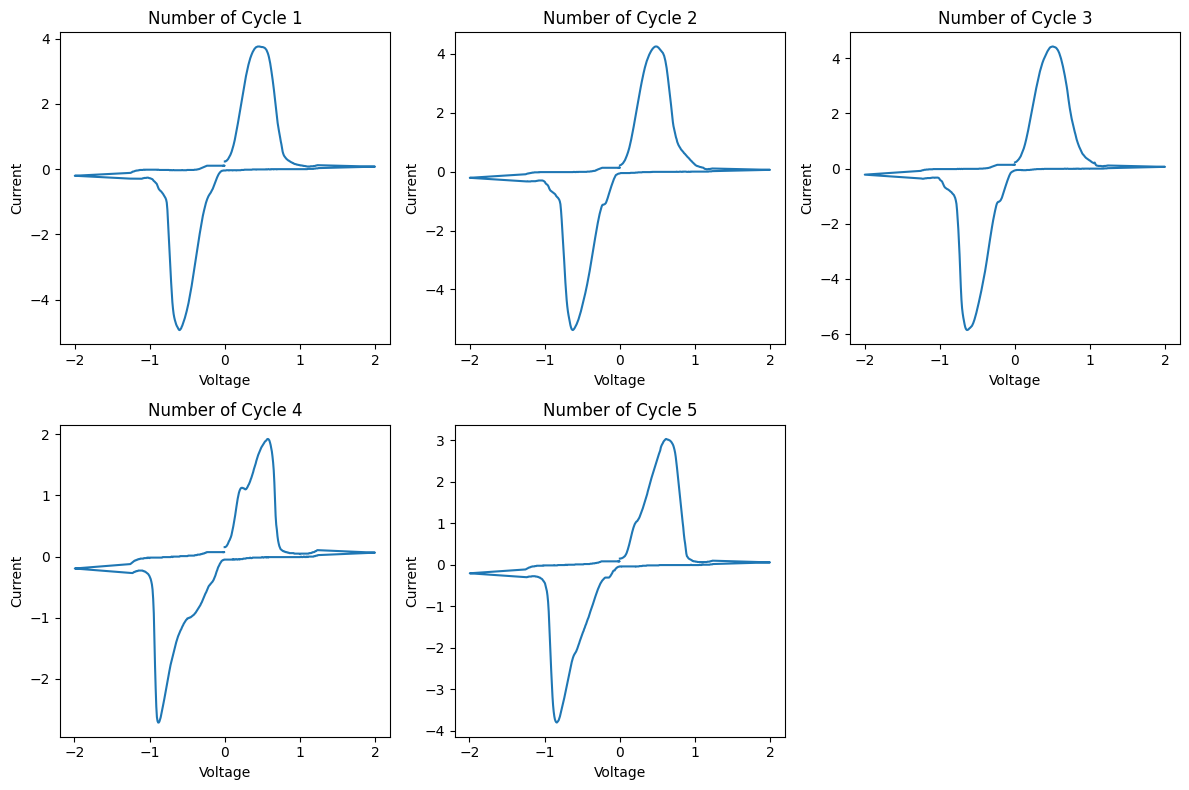

In [5]:
import math

def plot_full(vol, cur, num_columns):
    n = len(vol)
    n_cols = num_columns
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    if n_rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for i in range(n):
        ax = axes[i]
        ax.plot(vol.iloc[i], cur.iloc[i])
        ax.set_title(f"Number of Cycle {i+1}")
        ax.set_ylabel("Current")
        ax.set_xlabel("Voltage")
    
    for j in range(n, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
plot_full(prep.voltage.iloc[5:10], prep.current.iloc[5:10], 3)